In [1]:
import numpy as np
import os
import globals as gl
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from Plot import make_yref, set_spines_and_ticks_width, save_figure_incremental
from Plot import plot_force_aligned, annotate_finger_labels,auto_margin
plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response.svg


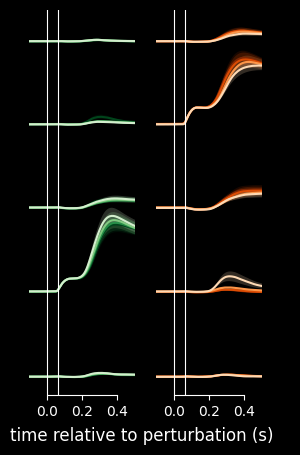

In [2]:
# === Load data ===
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

fig, axs = plt.subplots(1, 2, figsize=(3, 5), sharey=True, sharex=True)

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for f, finger in enumerate(descr.finger.unique()):
    for stimFinger in descr.stimFinger.unique():
        for cue in descr.cue.unique():
            force_tmp = force[(descr.cue == cue) & (descr.stimFinger == stimFinger) & (descr.finger == finger)]

            if stimFinger == 'index':
                ax=axs[0]
            else:
                ax=axs[1]

            y = force_tmp.mean(axis=0) + f * 15
            yerr = force_tmp.std(axis=0) / np.sqrt(force_tmp.shape[0])

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y - yerr, y + yerr, color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)
# # === Initialize figure ===
# fig, axs = plt.subplots(ncols=3, figsize=(8, 5))
# vsep_go, vsep_nogo = 15, 1.5
#
# colors_go = list(gl.colour_mapping.values())[5:10]
# colors_nogo = list(gl.colour_mapping.values())[0:5]
#
# # === Plotting ===
# plot_force_aligned(force, descr, 'go', vsep_go, axs)
# plot_force_aligned(force, descr,'nogo', vsep_nogo, axs)
# annotate_finger_labels(force, descr, axs[0], vsep_nogo)
#
# # === Titles and intervals ===
# for sf, stimF in enumerate(descr.stimFinger.unique()):
#     axs[sf].set_title(f'{stimF} perturbation' if stimF != 'nogo' else 'nogo trials')
#
# axs[0].axvspan(-1.5, 0, color='grey', alpha=.3, lw=0)
# axs[1].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
# axs[2].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
#
axs[0].set_xlim([-.1, .5])
axs[1].set_xlim([-.1, .5])
# axs[2].set_xlim([-.1, .5])
#
# axs[0].set_ylim([-.21, 6.90])
# axs[1].set_ylim(auto_margin(axs[1].lines))
# axs[2].set_ylim(auto_margin(axs[2].lines))
#
# axs[0].set_xticks([-1.5, 0, .4])
axs[0].set_xticks([0, .2, .4])
axs[1].set_xticks([0, .2, .4])
#
make_yref(axs[1], reference_length=5, pos='right')
# make_yref(axs[0], reference_length=.5, pos='left')
#
# axs[0].spines[['bottom']].set_bounds(-1.5, .4)
axs[0].spines[['bottom']].set_bounds(0, .4)
axs[1].spines[['bottom']].set_bounds(0, .4)

# === Styling ===
for ax in axs:
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes='x', which='both')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='w', lw=.8)
    ax.axvline(0.065, ls='-', color='w', lw=.8)
    ax.set_yticks([])
#
# # === Title and labels ===
# fig.suptitle('Force response to finger perturbation')
fig.supxlabel('time relative to perturbation (s)')
#
# # === Save and show ===
save_figure_incremental(fig, 'force_response')
# plt.show()

index: 0.04200000000000004 ms
ring: 0.050000000000000044 ms


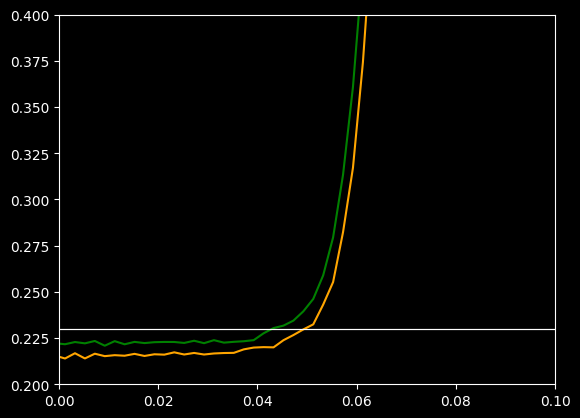

In [3]:
# === Load data ===
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

thresh = .230

fig, ax = plt.subplots()

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for stimFinger in descr.stimFinger.unique():
    if stimFinger == 'index':
        force_tmp = np.nanmean(force[(descr.stimFinger == stimFinger) & (descr.finger == 'index')], axis=0)
        color = 'green'
    if stimFinger == 'ring':
        force_tmp = np.nanmean(force[(descr.stimFinger == stimFinger) & (descr.finger == 'ring')], axis=0)
        color = 'orange'

    above_thresh = force_tmp > thresh
    latency = np.where(above_thresh==1)[0][0] / 500
    latency = latency - gl.prestim

    print(f'{stimFinger}: {latency} ms')

    ax.plot(tAx, force_tmp, color=color)
    ax.axhline(thresh, ls='-', color='w', lw=.8)
    ax.set_xlim([0, .1])
    ax.set_ylim([.2, .4])

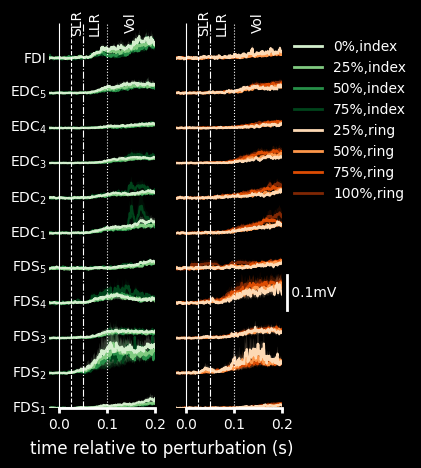

In [9]:
experiment = 'smp0'

f = open(os.path.join(gl.baseDir, experiment, 'emg', 'emg.p'), 'rb')
Dict = pickle.load(f)

# Time axis for each latency
tAx = np.linspace(-1, 2, 6444)

# Set up plot
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(3, 5))

# Vertical lines and associated styles
line_xs = [0, .025, .05, .1]
line_styles = ['-', '--', '-.', ':']
line_labels = ['SLR', 'LLR', 'Vol']

for ch, channel in enumerate(Dict.keys()):
    for c, cue in enumerate(gl.cues[::-1]):
        for s, stimFinger in enumerate(gl.stimFinger):

            ax = axs[s]

            data = np.array(Dict[channel])
            y = np.nanmean(data[:, c, s], axis=0) + ch * .1
            yerr = np.nanstd(data[:, c, s], axis=0) / np.sqrt(10)

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y- yerr, y + yerr,
                                color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)

            if (s == 0) & (c == 1):
                label = (f'FDS$_{{{ch+1}}}$' if ch < 5 else
                         f'EDC$_{{{ch-4}}}$' if (ch >= 5) & (ch < 10) else
                         'FDI' if ch == 10 else '')
                ax.text(-.025, y[0], label, va='center', ha='right',)

# Draw vertical lines
for ax in axs:
    ax.set_ylim((0, 1.1))
    for x, style in zip(line_xs, line_styles):
        ax.vlines(x, ymin=0, ymax=ax.get_ylim()[1], linestyles=style, color='w', lw=.8)

    ax.set_xlim([-.02, .2])

#     ax.set_ylim([0, 1.15])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Remove y-ticks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.spines['bottom'].set_bounds([0, .2])
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(width=2)
    ax.set_xticks([0, .1, .2])
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes=('x',), which='both')

    # Place text labels between key vertical lines
    xlims = ax.get_xlim()
    text_positions = [
        (.025 + .05) / 2,          # "SLR"
        (.05 + .1) / 2,            # "LLR"
        (.1 + xlims[1]) / 2        # "Vol"
    ]
    for label, xpos in zip(line_labels, text_positions):
        ax.text(xpos, ax.get_ylim()[1], label, ha='center', va='center',  rotation=90,)
#
# # Global labels and layout
fig.supxlabel('time relative to perturbation (s)')
# fig.suptitle('EMG response to finger perturbation')
make_yref(axs[1], reference_length=.1, pos='right', unit='mV', color='w')

# Create legend entries as colored lines (matching plotted lines)
legend_elements = []
for k,v in gl.colour_mapping.items():
    if 'ring' in k or 'index' in k:
        legend_elements.append(Line2D([0], [0], color=v, lw=2, label=k))

# Add the legend to the figure, outside the right edge
fig.legend(handles=legend_elements,
           loc='lower left',
           bbox_to_anchor=(.9, .5),
           frameon=False)

plt.show()


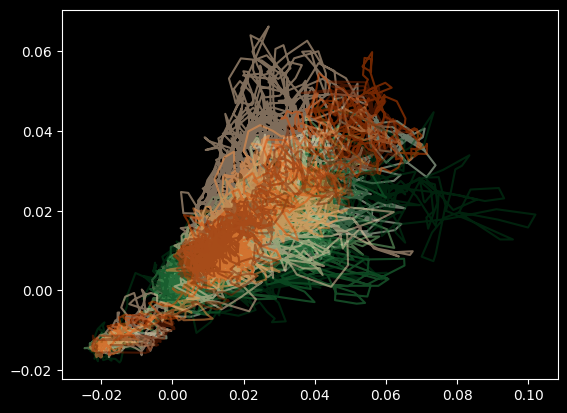

In [5]:
experiment = 'smp0'
snS = [100, 101, 102, 104, 105, 106, 107, 108, 109, 110]

pc = {
    '0%,index': [],
    '25%,index': [],
    '50%,index': [],
    '75%,index': [],
    '25%,ring': [],
    '50%,ring': [],
    '75%,ring': [],
    '100%,ring': [],
}

for sn in snS:
    pc_tmp = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'pcs.npy'))
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')

    dat.stimFinger = dat.stimFinger.map(gl.stimFinger_mapping)
    dat.cue = dat.cue.map(gl.cue_mapping)

    for cue in dat.cue.unique():
        for stimFinger in dat.stimFinger.unique():
            if f'{cue},{stimFinger}' in pc.keys():
                pc[f'{cue},{stimFinger}'].append(pc_tmp[(dat.cue == cue) & (dat.stimFinger == stimFinger)])

fig, ax = plt.subplots()

for k, v in pc.items():
    pc[k] = np.array(v).mean(axis=1)
    pc_avg = pc[k].mean(axis=0)
    ax.plot(pc_avg[0, 2148:2148 + int(1 * 2148)], pc_avg[1, 2148:2148 + int(1 * 2148)],color=gl.colour_mapping[k], alpha=.5)
